<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/dexpi_safety_study_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NeqSim to DEXPI P&ID and safety-study evidence

This notebook creates one calculated gas-processing `ProcessSystem`, writes three
explicit exchange profiles, inspects their semantic content, and builds a
traceable safety-study preparation pack:

- a Proteus P&ID exchange for NeqSim's current graphical equipment, piping,
  instrumentation, and HIPPS/SIS mapping;
- a native DEXPI 2.0 Plant/P&ID exchange with schema-and-profile conformance;
- an assessed native DEXPI 2.0 Process/PFD exchange driven by the canonical
  engineering graph, including stable topology, operating-case units,
  provenance, and structured loss evidence.

These artifacts are software-generated proposals and qualification evidence.
They are not approved P&IDs, construction documents, HAZOPs, SIL assessments,
relief designs, or operating procedures. Project teams must validate identifiers,
connectivity, units, design limits, safety functions, revisions, and approvals
against controlled engineering sources.


## Learning objectives

After completing the notebook, you can:

1. keep a composable NeqSim `ProcessSystem` as the calculated source model;
2. choose between NeqSim's Proteus and native DEXPI 2.0 export profiles;
3. inspect equipment, piping, instrumentation, and design-condition semantics;
4. distinguish native conformance from graphical and commercial round-trip
   qualification;
5. form HAZOP nodes and cause-and-effect records from stable identifiers;
6. calculate completeness and traceability indicators;
7. retain unsupported or unverified safety metadata in a governed study register.

## Standards and qualification boundary

- **DEXPI 2.0** defines information models and an official XML schema for
  process and plant information.
- NeqSim's **Proteus P&ID exchange** is a separate, useful graphical exchange
  profile. It currently carries NeqSim's richer HIPPS/SIS attributes.
- **IEC 62424:2016** covers representation of process-control engineering
  requests in P&IDs and exchange between engineering tools.
- **IEC 61882:2016** governs HAZOP preparation, examination, documentation,
  and follow-up.
- **IEC 61511:2016** governs the safety lifecycle when risk reduction is
  allocated to a safety instrumented function.

Native schema/profile conformance, semantic fidelity, rendered-P&ID quality, and
named CAE product/version round trips are distinct gates. This notebook observes
the first two NeqSim profiles; it does not claim a commercial-tool round trip or
accountable engineering approval.

## Data-quality model

Treat each exchange file as a semantic graph $G=(V,E)$, where $V$ contains
equipment, streams, instruments, and safety functions, while $E$ contains
process and signal connectivity.

For a study object with $n_{\mathrm{required}}$ required attributes and
$n_{\mathrm{verified}}$ verified attributes, define:

$$C = \frac{n_{\mathrm{verified}}}{n_{\mathrm{required}}}$$

`Present` is weaker than `verified`: a tag may exist while its safety role,
voting, trip set point, proof-test interval, safe state, source revision, or
approval state remains absent or external to the selected exchange profile.

In [1]:
%pip install -q "neqsim>=3.17.0" "pandas>=2.2" "matplotlib>=3.8"


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Reproducible current-master runtime

The public-PyPI `neqsim` package supplies the Python bridge. The Java runtime is
built from the selected `equinor/neqsim` source ref, and the notebook records the
resolved commit, JAR digest, and loaded class location. Set
`NEQSIM_SOURCE_REF` to reproduce another reviewed commit. Validation automation
may instead provide `NEQSIM_SOURCE_ROOT` and `NEQSIM_SOURCE_JAR` from an exact
checked-out build.


In [2]:
import hashlib
import importlib.util
import os
from pathlib import Path
import subprocess

import jpype


def run_command(command, *, cwd=None, timeout=1800, environment=None):
    result = subprocess.run(
        command,
        cwd=cwd,
        env=environment,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=timeout,
    )
    if result.returncode != 0:
        tail = "\n".join(result.stdout.splitlines()[-80:])
        raise RuntimeError(
            f"Command failed ({result.returncode}): {command}\n{tail}"
        )
    return result.stdout.strip()


NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
supplied_source = os.environ.get("NEQSIM_SOURCE_ROOT", "").strip()
supplied_jar = os.environ.get("NEQSIM_SOURCE_JAR", "").strip()

if supplied_source and supplied_jar:
    neqsim_source = Path(supplied_source).resolve()
    neqsim_jar = Path(supplied_jar).resolve()
else:
    build_root = Path("/content") if Path("/content").exists() else Path.cwd()
    neqsim_source = build_root / "neqsim-java-master"
    if not neqsim_source.exists():
        run_command(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                NEQSIM_SOURCE_REF,
                "https://github.com/equinor/neqsim.git",
                str(neqsim_source),
            ],
            timeout=600,
        )
    else:
        run_command(
            ["git", "fetch", "--depth", "1", "origin", NEQSIM_SOURCE_REF],
            cwd=neqsim_source,
            timeout=600,
        )
        run_command(
            ["git", "checkout", "--detach", "FETCH_HEAD"],
            cwd=neqsim_source,
        )

    maven_settings = build_root / "neqsim-maven-settings.xml"
    maven_settings.write_text(
        "<settings><mirrors><mirror>"
        "<id>canonical-central</id><mirrorOf>central</mirrorOf>"
        "<url>https://repo.maven.apache.org/maven2/</url>"
        "</mirror></mirrors></settings>",
        encoding="utf-8",
    )
    run_command(
        [
            "./mvnw",
            "-q",
            "-s",
            str(maven_settings),
            "-DskipTests",
            "-Dmaven.javadoc.skip=true",
            "package",
        ],
        cwd=neqsim_source,
        timeout=1800,
    )
    built_jars = [
        path
        for path in (neqsim_source / "target").glob("neqsim-*.jar")
        if "sources" not in path.name
        and "javadoc" not in path.name
        and not path.name.startswith("original-")
    ]
    if not built_jars:
        raise FileNotFoundError("Maven completed but no NeqSim JAR was found.")
    neqsim_jar = max(built_jars, key=lambda path: path.stat().st_size)

if not neqsim_source.is_dir() or not neqsim_jar.is_file():
    raise FileNotFoundError("NeqSim source root or built JAR is missing.")

neqsim_commit = run_command(["git", "rev-parse", "HEAD"], cwd=neqsim_source)
neqsim_jar_sha256 = hashlib.sha256(neqsim_jar.read_bytes()).hexdigest()

os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
if not jpype.isJVMStarted():
    jpype.addClassPath(str(neqsim_jar))
    neqsim_package = importlib.util.find_spec("neqsim")
    if neqsim_package is None or not neqsim_package.submodule_search_locations:
        raise ImportError("The public-PyPI neqsim bridge is not installed.")
    neqsim_python_root = Path(
        next(iter(neqsim_package.submodule_search_locations))
    )
    for runtime_jar in sorted((neqsim_python_root / "lib").glob("*.jar")):
        if runtime_jar.resolve() != neqsim_jar:
            jpype.addClassPath(str(runtime_jar))
    jpype.startJVM()

DexpiProcessWriter = jpype.JClass(
    "neqsim.process.processmodel.dexpi.Dexpi20ProcessModelWriter"
)
class_source = str(
    DexpiProcessWriter.class_.getProtectionDomain().getCodeSource().getLocation()
)
if neqsim_jar.name not in class_source:
    raise RuntimeError("NeqSim classes were not loaded from the source-built JAR.")


In [3]:
import importlib.metadata
import json
import platform
import sys
from xml.etree import ElementTree as ET

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib import patches

from neqsim import jneqsim as ns

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
    }
)

runtime = {
    "neqsim": importlib.metadata.version("neqsim"),
    "python": platform.python_version(),
    "java": str(jpype.java.lang.System.getProperty("java.version")),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
    "neqsim_java_commit": neqsim_commit,
    "neqsim_jar_sha256": neqsim_jar_sha256,
    "neqsim_java_class_source": class_source,
}
display(pd.DataFrame([runtime]).T.rename(columns={0: "version"}))


,version
neqsim,3.17.0
python,3.12.13
java,17.0.19
numpy,2.5.2
pandas,3.0.5
matplotlib,3.11.1
neqsim_java_commit,12b0e2fab3c4ea244a810e8058ca57c08e72631f
neqsim_jar_sha256,fc16ab4be4eda4970b50c6b4d7dfca43047493aa09d7db...
neqsim_java_class_source,file:/home/runner/work/NeqSim-Colab/NeqSim-Col...


## Design basis

The synthetic case represents a 90 bara rich-gas feed protected by a 2oo3
pressure-sensing HIPPS. Two downstream pressure levels and a 100 bara separator
design pressure create a useful traceability case.

In [4]:
design_basis = pd.DataFrame(
    [
        ["Feed flow", 60_000.0, "kg/h", "Normal operation"],
        ["Feed pressure", 90.0, "bara", "Upstream source"],
        ["Separator pressure", 75.0, "bara", "Protected system"],
        ["Separator design pressure", 100.0, "bara", "Illustrative"],
        ["Relief set pressure", 95.0, "bara", "Illustrative"],
        ["HIPPS trip set point", 82.0, "bara", "Study register"],
        ["HIPPS voting", "2oo3", "-", "Study register"],
        ["HIPPS closure time", 6.0, "s", "Study register"],
    ],
    columns=["Parameter", "Value", "Unit", "Data owner"],
)
display(design_basis)

,Parameter,Value,Unit,Data owner
0,Feed flow,60000.0,kg/h,Normal operation
1,Feed pressure,90.0,bara,Upstream source
2,Separator pressure,75.0,bara,Protected system
3,Separator design pressure,100.0,bara,Illustrative
4,Relief set pressure,95.0,bara,Illustrative
5,HIPPS trip set point,82.0,bara,Study register
6,HIPPS voting,2oo3,-,Study register
7,HIPPS closure time,6.0,s,Study register


## Build and run the native process model

In [5]:
components = [
    ("nitrogen", 0.010),
    ("CO2", 0.020),
    ("methane", 0.860),
    ("ethane", 0.070),
    ("propane", 0.040),
]

fluid = ns.thermo.system.SystemSrkEos(308.15, 90.0)
for component, mole_fraction in components:
    fluid.addComponent(component, mole_fraction)
fluid.createDatabase(True)
fluid.setMixingRule(2)
fluid.setMultiPhaseCheck(True)

feed = ns.process.equipment.stream.Stream("Feed-101", fluid)
feed.setFlowRate(60_000.0, "kg/hr")

hipps = ns.process.equipment.valve.HIPPSValve("HIPPS-XV-101", feed)
hipps.setOutletPressure(75.0, "bara")
hipps.setClosureTime(6.0)
hipps.setSILRating(3)
hipps.setProofTestInterval(8760.0)
hipps.setVotingLogic(
    ns.process.equipment.valve.HIPPSValve.VotingLogic.TWO_OUT_OF_THREE
)

separator = ns.process.equipment.separator.Separator(
    "V-101 HP Separator",
    hipps.getOutletStream(),
)
compressor = ns.process.equipment.compressor.Compressor(
    "K-101 Export Compressor",
    separator.getGasOutStream(),
)
compressor.setOutletPressure(105.0, "bara")
compressor.setIsentropicEfficiency(0.75)

aftercooler = ns.process.equipment.heatexchanger.Cooler(
    "E-101 Export Aftercooler",
    compressor.getOutletStream(),
)
aftercooler.setOutTemperature(313.15)

design = ns.process.mechanicaldesign.DesignConditions()
design.setDesignPressure(100.0)
design.setMaxDesignTemperature(120.0)
design.setMinDesignTemperature(-29.0)
design.setReliefSetPressure(95.0)
design.setConstructionMaterial("Carbon steel - illustrative")
separator.setDesignConditions(design)

transmitters = []
for suffix in ["A", "B", "C"]:
    tag = f"PSHH-101{suffix}"
    transmitter = ns.process.measurementdevice.PressureTransmitter(tag, feed)
    transmitter.setTagName(tag)
    transmitter.setUnit("bara")
    transmitter.setMinimumValue(0.0)
    transmitter.setMaximumValue(120.0)
    hipps.addPressureTransmitter(transmitter)
    transmitters.append(transmitter)

process = ns.process.processmodel.ProcessSystem()
for unit in [
    feed,
    hipps,
    separator,
    compressor,
    aftercooler,
    *transmitters,
]:
    process.add(unit)
process.run()

In [6]:
mass_in = float(feed.getFlowRate("kg/hr"))
mass_out = float(
    separator.getGasOutStream().getFlowRate("kg/hr")
    + separator.getLiquidOutStream().getFlowRate("kg/hr")
)
process_results = pd.DataFrame(
    [
        ["Feed pressure", feed.getPressure("bara"), "bara"],
        ["HIPPS outlet pressure", hipps.getOutletPressure(), "bara"],
        [
            "Separator gas temperature",
            separator.getGasOutStream().getTemperature("C"),
            "°C",
        ],
        [
            "Compressor discharge pressure",
            compressor.getOutletPressure(),
            "bara",
        ],
        [
            "Aftercooler outlet temperature",
            aftercooler.getOutletStream().getTemperature("C"),
            "°C",
        ],
        ["Mass-balance relative error", abs(mass_in - mass_out) / mass_in, "-"],
    ],
    columns=["Result", "Value", "Unit"],
)
display(process_results)

,Result,Value,Unit
0,Feed pressure,90.000000,bara
1,HIPPS outlet pressure,75.000000,bara
2,Separator gas temperature,28.943467,°C
3,Compressor discharge pressure,105.000000,bara
4,Aftercooler outlet temperature,40.000000,°C
5,Mass-balance relative error,0.000000,-


## Calculated process with safety-study overlay

Blue objects are process equipment. Orange objects are safety-study records that
must retain traceable links even when an exchange schema does not carry all their
lifecycle attributes.

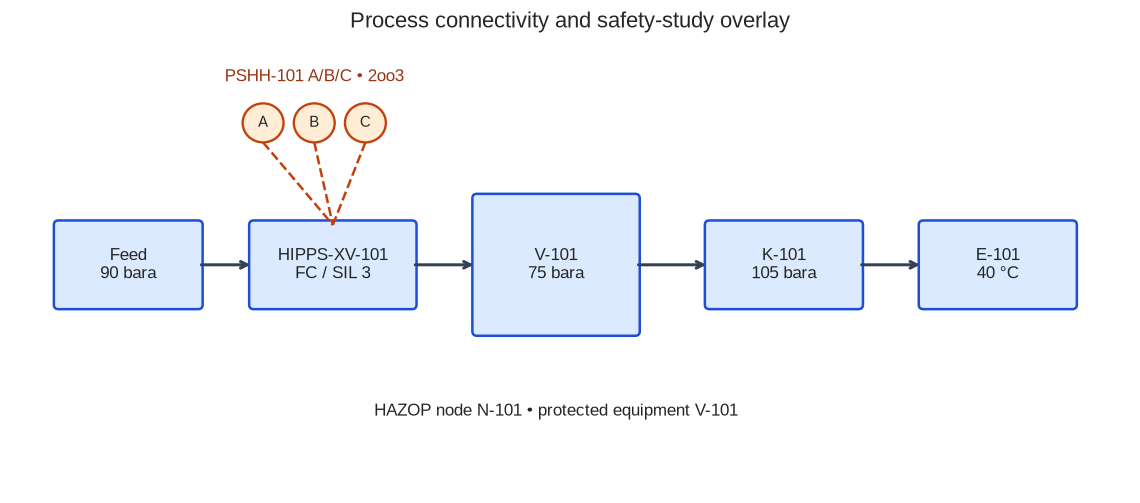

In [7]:
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 5)
ax.axis("off")

equipment = [
    (0.5, 2.1, 1.5, 0.9, "Feed\n90 bara"),
    (2.6, 2.1, 1.7, 0.9, "HIPPS-XV-101\nFC / SIL 3"),
    (5.0, 1.8, 1.7, 1.5, "V-101\n75 bara"),
    (7.5, 2.1, 1.6, 0.9, "K-101\n105 bara"),
    (9.8, 2.1, 1.6, 0.9, "E-101\n40 °C"),
]
for x, y, width, height, label in equipment:
    box = patches.FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.05",
        facecolor="#dbeafe",
        edgecolor="#1d4ed8",
        linewidth=1.5,
    )
    ax.add_patch(box)
    ax.text(x + width / 2, y + height / 2, label, ha="center", va="center")

for x0, x1 in [(2.0, 2.6), (4.3, 5.0), (6.7, 7.5), (9.1, 9.8)]:
    ax.annotate(
        "",
        xy=(x1, 2.55),
        xytext=(x0, 2.55),
        arrowprops={"arrowstyle": "->", "color": "#334155", "lw": 1.8},
    )

for index, suffix in enumerate(["A", "B", "C"]):
    x = 2.7 + index * 0.55
    sensor = patches.Circle(
        (x, 4.15),
        0.22,
        facecolor="#ffedd5",
        edgecolor="#c2410c",
        linewidth=1.4,
    )
    ax.add_patch(sensor)
    ax.text(x, 4.15, suffix, ha="center", va="center", fontsize=9)
    ax.plot([x, 3.45], [3.93, 3.0], color="#c2410c", linestyle="--")
ax.text(3.25, 4.62, "PSHH-101 A/B/C • 2oo3", ha="center", color="#9a3412")
ax.text(5.85, 0.85, "HAZOP node N-101 • protected equipment V-101", ha="center")
ax.set_title("Process connectivity and safety-study overlay", pad=12)
plt.show()

## Export three explicit exchange profiles

The same calculated `ProcessSystem` is written through three current NeqSim APIs.
`DexpiXmlWriter.write` provides the Proteus P&ID exchange used for the semantic
and graphical inventory below. `Dexpi20XmlWriter.writeAndAssess` provides the
native DEXPI 2.0 Plant/P&ID file. The opt-in five-argument
`Dexpi20ProcessModelWriter.writeAndAssessTopology` path provides a native DEXPI
2.0 Process/PFD exchange driven by one canonical graph and operating case.

All profiles are written twice to test determinism. Native DEXPI 2.0 files and
reports are compared byte for byte. Proteus `PlantInformation` intentionally
records the export date and time, so its engineering-semantic fingerprint
excludes only those two volatile attributes. Raw SHA-256 values still identify
the exact payloads generated in this run.


In [8]:
def semantic_sha256(xml_payload):
    semantic_root = ET.fromstring(xml_payload)
    for element in semantic_root.iter():
        if element.tag.split("}")[-1] != "PlantInformation":
            continue
        element.attrib.pop("Date", None)
        element.attrib.pop("Time", None)
    semantic_payload = ET.tostring(
        semantic_root,
        encoding="utf-8",
    )
    return hashlib.sha256(semantic_payload).hexdigest()


proteus_path = Path("proteus_pid_safety_study.xml")
proteus_file = jpype.JClass("java.io.File")(str(proteus_path.absolute()))
proteus_writer = ns.process.processmodel.dexpi.DexpiXmlWriter
proteus_writer.write(process, proteus_file)

proteus_repeat_path = Path("proteus_pid_safety_study_repeat.xml")
proteus_repeat_file = jpype.JClass("java.io.File")(
    str(proteus_repeat_path.absolute())
)
proteus_writer.write(process, proteus_repeat_file)

native_path = Path("native_dexpi_20_plant_pid.xml")
native_file = jpype.JClass("java.io.File")(str(native_path.absolute()))
native_writer = ns.process.processmodel.dexpi.Dexpi20XmlWriter
native_report = native_writer.writeAndAssess(process, native_file)
native_report_data = json.loads(str(native_report.toJson()))

native_repeat_path = Path("native_dexpi_20_plant_pid_repeat.xml")
native_repeat_file = jpype.JClass("java.io.File")(
    str(native_repeat_path.absolute())
)
native_repeat_report = native_writer.writeAndAssess(
    process,
    native_repeat_file,
)

process_path = Path("native_dexpi_20_process_pfd.xml")
process_file = jpype.JClass("java.io.File")(str(process_path.absolute()))
process_writer = ns.process.processmodel.dexpi.Dexpi20ProcessModelWriter
process_report = process_writer.writeAndAssessTopology(
    process,
    process_file,
    "GAS-SAFETY-STUDY",
    "A",
    "NORMAL-001",
)
process_report_data = json.loads(str(process_report.toJson()))
process_report_path = Path(
    "native_dexpi_20_process_pfd.topology.json"
)
process_report_path.write_text(
    str(process_report.toJson()),
    encoding="utf-8",
)

process_repeat_path = Path("native_dexpi_20_process_pfd_repeat.xml")
process_repeat_file = jpype.JClass("java.io.File")(
    str(process_repeat_path.absolute())
)
process_repeat_report = process_writer.writeAndAssessTopology(
    process,
    process_repeat_file,
    "GAS-SAFETY-STUDY",
    "A",
    "NORMAL-001",
)

proteus_payload = proteus_path.read_bytes()
proteus_repeat_payload = proteus_repeat_path.read_bytes()
native_payload = native_path.read_bytes()
native_repeat_payload = native_repeat_path.read_bytes()
process_payload = process_path.read_bytes()
process_repeat_payload = process_repeat_path.read_bytes()
proteus_root = ET.fromstring(proteus_payload)
native_root = ET.fromstring(native_payload)
process_root = ET.fromstring(process_payload)

plant_information = next(
    element
    for element in proteus_root.iter()
    if element.tag.split("}")[-1] == "PlantInformation"
)
proteus_schema_version = plant_information.attrib.get("SchemaVersion", "")
proteus_semantic_digest = semantic_sha256(proteus_payload)
proteus_repeat_semantic_digest = semantic_sha256(proteus_repeat_payload)
native_status = native_report_data["status"]
process_status = process_report_data["conformance"]["status"]
process_diagnostic_codes = [
    str(diagnostic.getCode())
    for diagnostic in process_report.getDiagnostics()
]
process_diagnostics = pd.DataFrame(
    [
        {
            "Severity": str(diagnostic.getSeverity()),
            "Code": str(diagnostic.getCode()),
            "Subject": str(diagnostic.getSubject()),
            "Message": str(diagnostic.getMessage()),
        }
        for diagnostic in process_report.getDiagnostics()
    ]
)
process_diagnostic_summary = (
    process_diagnostics.groupby(["Severity", "Code"])
    .size()
    .reset_index(name="Count")
)
missing_value_subjects = process_diagnostics.loc[
    process_diagnostics["Code"]
    == "DEXPI_PROCESS_OPERATING_VALUE_MISSING",
    ["Subject", "Message"],
]

export_evidence = pd.DataFrame(
    [
        [
            "Proteus P&ID",
            proteus_path.name,
            proteus_root.tag.split("}")[-1],
            proteus_schema_version,
            hashlib.sha256(proteus_payload).hexdigest(),
            proteus_semantic_digest,
            len(proteus_payload),
        ],
        [
            "Native DEXPI 2.0 Plant/P&ID",
            native_path.name,
            native_root.tag.split("}")[-1],
            native_status,
            hashlib.sha256(native_payload).hexdigest(),
            hashlib.sha256(native_payload).hexdigest(),
            len(native_payload),
        ],
        [
            "Native DEXPI 2.0 Process/PFD",
            process_path.name,
            process_root.tag.split("}")[-1],
            process_status,
            hashlib.sha256(process_payload).hexdigest(),
            hashlib.sha256(process_payload).hexdigest(),
            len(process_payload),
        ],
    ],
    columns=[
        "Profile",
        "File",
        "Root",
        "Schema/profile evidence",
        "Raw SHA-256",
        "Engineering-semantic SHA-256",
        "Bytes",
    ],
)
display(export_evidence)
display(process_diagnostic_summary)
display(missing_value_subjects)

profile_baseline = pd.DataFrame(
    [
        [
            "Proteus P&ID",
            "DexpiXmlWriter.write",
            "Equipment, connectivity, instruments, HIPPS/SIS attributes",
            "Generated; semantic fingerprint stable on repeat",
        ],
        [
            "Native DEXPI 2.0 Plant/P&ID",
            "Dexpi20XmlWriter.writeAndAssess",
            "Official schema, imports, references, supported semantic profile",
            f"{native_status}; byte-stable on repeat",
        ],
        [
            "Native DEXPI 2.0 Process/PFD/BFD",
            "Dexpi20ProcessModelWriter.writeAndAssessTopology",
            "Canonical material topology, case values, units, provenance, losses",
            f"{process_status}; byte-stable on repeat",
        ],
        [
            "Governed engineering package",
            "DexpiEngineeringExporter",
            "Provenance, revisions, registers, validation, and manifests",
            "Required for controlled project deliverables; not exercised here",
        ],
    ],
    columns=["Capability", "Current NeqSim API", "Evidence boundary", "This run"],
)
display(profile_baseline)

payload = proteus_payload
root = proteus_root


,Profile,File,Root,Schema/profile evidence,Raw SHA-256,Engineering-semantic SHA-256,Bytes
0,Proteus P&ID,proteus_pid_safety_study.xml,PlantModel,4.1.1,a0fdd4cbb6ff30cf7086263b1e40f6be69860dbfcf2cdb...,07473045399c2a4e78f38716ec5488623239e4e5ba9ba6...,141391
1,Native DEXPI 2.0 Plant/P&ID,native_dexpi_20_plant_pid.xml,Model,CONFORMANT,3870f349952d4920f6e6fdb8840cfc6e9a6e2a3bbc8588...,3870f349952d4920f6e6fdb8840cfc6e9a6e2a3bbc8588...,9749
2,Native DEXPI 2.0 Process/PFD,native_dexpi_20_process_pfd.xml,Model,CONFORMANT,061ad6ddbb7f940ef20413452925f685b03ec8b5e847c0...,061ad6ddbb7f940ef20413452925f685b03ec8b5e847c0...,17463


,Severity,Code,Count
0,INFO,DEXPI_PROCESS_BOUNDARY_SINK_SYNTHESIZED,2
1,WARNING,DEXPI_PROCESS_DOCUMENT_SEMANTICS_UNSUPPORTED,1
2,WARNING,DEXPI_PROCESS_GRAPHICS_UNSUPPORTED,1
3,WARNING,DEXPI_PROCESS_MULTI_AREA_UNSUPPORTED,1
4,WARNING,DEXPI_PROCESS_OPERATING_VALUE_MISSING,15


,Subject,Message
0,equipment:gas-safety-study-process-system-hipp...,No matching canonical calculation node was ava...
1,equipment:gas-safety-study-process-system-hipp...,No matching canonical calculation node was ava...
2,equipment:gas-safety-study-process-system-hipp...,No matching canonical calculation node was ava...
3,equipment:gas-safety-study-process-system-v-10...,No matching canonical calculation node was ava...
4,equipment:gas-safety-study-process-system-v-10...,No matching canonical calculation node was ava...
5,equipment:gas-safety-study-process-system-v-10...,No matching canonical calculation node was ava...
6,equipment:gas-safety-study-process-system-k-10...,No matching canonical calculation node was ava...
7,equipment:gas-safety-study-process-system-k-10...,No matching canonical calculation node was ava...
8,equipment:gas-safety-study-process-system-k-10...,No matching canonical calculation node was ava...
9,liquidOutStream/massFlow,No matching canonical calculation node was ava...


,Capability,Current NeqSim API,Evidence boundary,This run
0,Proteus P&ID,DexpiXmlWriter.write,"Equipment, connectivity, instruments, HIPPS/SI...",Generated; semantic fingerprint stable on repeat
1,Native DEXPI 2.0 Plant/P&ID,Dexpi20XmlWriter.writeAndAssess,"Official schema, imports, references, supporte...",CONFORMANT; byte-stable on repeat
2,Native DEXPI 2.0 Process/PFD/BFD,Dexpi20ProcessModelWriter.writeAndAssessTopology,"Canonical material topology, case values, unit...",CONFORMANT; byte-stable on repeat
3,Governed engineering package,DexpiEngineeringExporter,"Provenance, revisions, registers, validation, ...",Required for controlled project deliverables; ...


## Proteus P&ID semantic inventory and connectivity checks

The inventory below is taken from the Proteus artifact. It is not evidence that
the native DEXPI 2.0 artifact carries the same extension attributes.

In [9]:
def local_name(element):
    return element.tag.split("}")[-1]


def generic_attribute_map(elements):
    attributes = {}
    for element in elements:
        if local_name(element) != "GenericAttribute":
            continue
        name = element.attrib.get("Name", "")
        attributes.setdefault(name, []).append(
            {
                "value": element.attrib.get("Value", ""),
                "unit": element.attrib.get("Unit", ""),
            }
        )
    return attributes


def has_generic_attribute(attributes, name, value=None, unit=None):
    candidates = attributes.get(name, [])
    for candidate in candidates:
        value_matches = value is None or candidate["value"] == str(value)
        unit_matches = unit is None or candidate["unit"] == unit
        if value_matches and unit_matches:
            return True
    return False


elements = list(root.iter())
native_elements = list(native_root.iter())
proteus_attributes = generic_attribute_map(elements)
native_attributes = generic_attribute_map(native_elements)
local_names = pd.Series([local_name(element) for element in elements])

inventory_names = [
    "Equipment",
    "PipingNetworkSegment",
    "PipingNetworkSystem",
    "ProcessInstrumentationFunction",
    "InstrumentationLoopFunction",
    "Nozzle",
]
inventory = pd.DataFrame(
    {
        "Proteus object": inventory_names,
        "Count": [
            sum(
                local_name(element) == name
                and bool(element.attrib.get("ComponentClass"))
                for element in elements
            )
            for name in inventory_names
        ],
    }
)
display(inventory)

tagged_elements = []
for element in elements:
    element_type = local_name(element)
    tag = element.attrib.get("ID", "")
    if element_type in [
        "Equipment",
        "PipingComponent",
        "ProcessInstrumentationFunction",
    ]:
        tagged_elements.append(
            {
                "Element": element_type,
                "Tag": tag,
                "Class": element.attrib.get("ComponentClass", ""),
            }
        )
tagged_frame = pd.DataFrame(tagged_elements)
mask = tagged_frame["Tag"].str.contains(
    "V-101|K-101|E-101|HIPPS|PSHH",
    regex=True,
    na=False,
)
display(tagged_frame.loc[mask].drop_duplicates().reset_index(drop=True))

,Proteus object,Count
0,Equipment,3
1,PipingNetworkSegment,4
2,PipingNetworkSystem,1
3,ProcessInstrumentationFunction,3
4,InstrumentationLoopFunction,3
5,Nozzle,9


,Element,Tag,Class
0,Equipment,V-101-HP-Separator,Separator
1,Equipment,K-101-Export-Compressor,CentrifugalCompressor
2,Equipment,E-101-Export-Aftercooler,AirCoolingSystem
3,PipingComponent,HIPPS-XV-101,GateValve
4,ProcessInstrumentationFunction,PSHH-101A,ProcessInstrumentationFunction
5,ProcessInstrumentationFunction,PSHH-101B,ProcessInstrumentationFunction
6,ProcessInstrumentationFunction,PSHH-101C,ProcessInstrumentationFunction


## Safety semantics audit

The audit uses exact `GenericAttribute` names, values, and units rather than
substring matches. It separates:

- **Proteus exchange evidence** observed in this run;
- **native DEXPI 2.0 evidence** observed in this run;
- **study-register authority** that still requires verification and governance.

A software mapping can be present without being reviewed or approved.

In [10]:
hipps_rows = tagged_frame.loc[
    tagged_frame["Tag"] == "HIPPS-XV-101"
]
hipps_gate_valve = (
    not hipps_rows.empty
    and (hipps_rows["Class"] == "GateValve").any()
)

audit_rows = [
    [
        "V-101 design pressure",
        "100 bara",
        has_generic_attribute(
            proteus_attributes,
            "DesignPressure",
            "100",
            "bara",
        ),
        has_generic_attribute(
            native_attributes,
            "DesignPressure",
            "100",
            "bara",
        ),
        "Mechanical design basis",
    ],
    [
        "V-101 minimum design temperature",
        "-29 °C",
        has_generic_attribute(
            proteus_attributes,
            "MinimumDesignTemperature",
            "-29",
            "C",
        ),
        has_generic_attribute(
            native_attributes,
            "MinimumDesignTemperature",
            "-29",
            "C",
        ),
        "Mechanical design basis",
    ],
    [
        "HIPPS final-element class",
        "GateValve",
        hipps_gate_valve,
        False,
        "P&ID / SRS",
    ],
    [
        "SIL target",
        "SIL 3",
        has_generic_attribute(
            proteus_attributes,
            "SafetyIntegrityLevel",
            "3",
        ),
        has_generic_attribute(
            native_attributes,
            "SafetyIntegrityLevel",
            "3",
        ),
        "LOPA / SRS",
    ],
    [
        "Voting architecture",
        "2oo3",
        has_generic_attribute(
            proteus_attributes,
            "VotingArchitecture",
            "2oo3",
        ),
        has_generic_attribute(
            native_attributes,
            "VotingArchitecture",
            "2oo3",
        ),
        "SRS",
    ],
    [
        "Proof-test interval",
        "8760 h",
        has_generic_attribute(
            proteus_attributes,
            "ProofTestInterval",
            "8760",
            "h",
        ),
        has_generic_attribute(
            native_attributes,
            "ProofTestInterval",
            "8760",
            "h",
        ),
        "SRS / maintenance",
    ],
    [
        "Closure time",
        "6 s",
        has_generic_attribute(
            proteus_attributes,
            "ClosureTime",
            "6",
            "s",
        ),
        has_generic_attribute(
            native_attributes,
            "ClosureTime",
            "6",
            "s",
        ),
        "C&E / vendor data",
    ],
    [
        "Safe state",
        "Closed",
        has_generic_attribute(
            proteus_attributes,
            "SafeState",
            "Closed",
        ),
        has_generic_attribute(
            native_attributes,
            "SafeState",
            "Closed",
        ),
        "P&ID / C&E",
    ],
    [
        "Control system",
        "SIS",
        has_generic_attribute(
            proteus_attributes,
            "ControlSystem",
            "SIS",
        ),
        has_generic_attribute(
            native_attributes,
            "ControlSystem",
            "SIS",
        ),
        "P&ID / SRS",
    ],
    [
        "Trip set point",
        "82 bara",
        has_generic_attribute(
            proteus_attributes,
            "TripSetPoint",
            "82",
            "bara",
        ),
        has_generic_attribute(
            native_attributes,
            "TripSetPoint",
            "82",
            "bara",
        ),
        "SRS / C&E",
    ],
]
semantics_audit = pd.DataFrame(
    audit_rows,
    columns=[
        "Required semantic",
        "Expected",
        "Proteus evidence",
        "Native DEXPI 2.0 evidence",
        "Authority",
    ],
)
semantics_audit["Engineering state"] = np.where(
    semantics_audit["Proteus evidence"],
    "Calculated mapping - verify",
    "External register - verify",
)
display(semantics_audit)

,Required semantic,Expected,Proteus evidence,Native DEXPI 2.0 evidence,Authority,Engineering state
0,V-101 design pressure,100 bara,True,False,Mechanical design basis,Calculated mapping - verify
1,V-101 minimum design temperature,-29 °C,True,False,Mechanical design basis,Calculated mapping - verify
2,HIPPS final-element class,GateValve,True,False,P&ID / SRS,Calculated mapping - verify
3,SIL target,SIL 3,True,False,LOPA / SRS,Calculated mapping - verify
4,Voting architecture,2oo3,True,False,SRS,Calculated mapping - verify
5,Proof-test interval,8760 h,True,False,SRS / maintenance,Calculated mapping - verify
6,Closure time,6 s,True,False,C&E / vendor data,Calculated mapping - verify
7,Safe state,Closed,True,False,P&ID / C&E,Calculated mapping - verify
8,Control system,SIS,True,False,P&ID / SRS,Calculated mapping - verify
9,Trip set point,82 bara,False,False,SRS / C&E,External register - verify


## Semantic graph view

The graph below is a study-oriented projection, not a full P&ID renderer. It
exposes the relationships needed to ask whether every hazardous node, safety
function, final element, and protected item has a stable identifier.

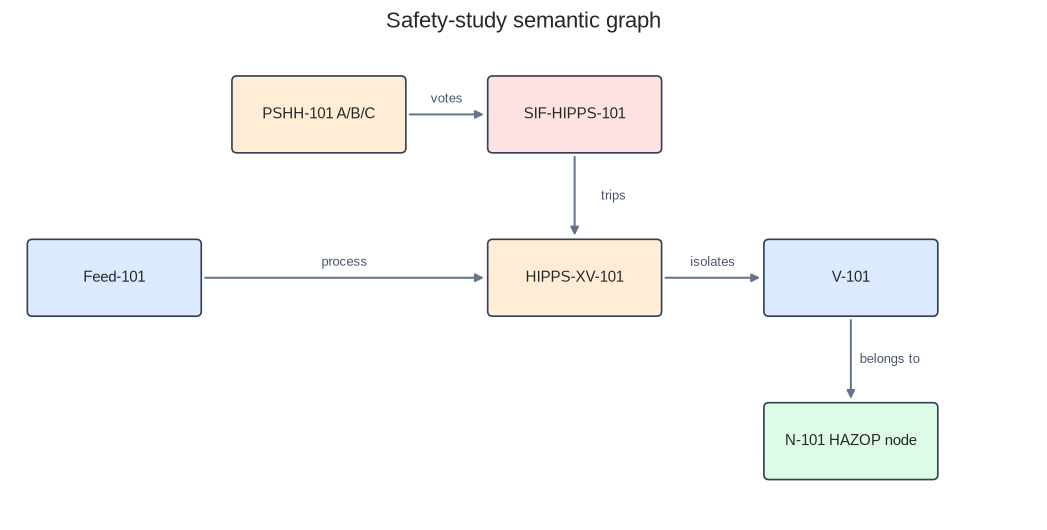

In [11]:
nodes = {
    "Feed-101": (1.0, 2.5, "#dbeafe"),
    "PSHH-101 A/B/C": (3.0, 4.2, "#ffedd5"),
    "SIF-HIPPS-101": (5.5, 4.2, "#fee2e2"),
    "HIPPS-XV-101": (5.5, 2.5, "#ffedd5"),
    "V-101": (8.2, 2.5, "#dbeafe"),
    "N-101 HAZOP node": (8.2, 0.8, "#dcfce7"),
}
edges = [
    ("Feed-101", "HIPPS-XV-101", "process"),
    ("PSHH-101 A/B/C", "SIF-HIPPS-101", "votes"),
    ("SIF-HIPPS-101", "HIPPS-XV-101", "trips"),
    ("HIPPS-XV-101", "V-101", "isolates"),
    ("V-101", "N-101 HAZOP node", "belongs to"),
]

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis("off")

node_boxes = {}
for label, (x, y, color) in nodes.items():
    box = patches.FancyBboxPatch(
        (x - 0.8, y - 0.35),
        1.6,
        0.7,
        boxstyle="round,pad=0.05",
        facecolor=color,
        edgecolor="#334155",
    )
    node_boxes[label] = box
    ax.add_patch(box)
    ax.text(x, y, label, ha="center", va="center", fontsize=9)

for source, target, relation in edges:
    x0, y0, _ = nodes[source]
    x1, y1, _ = nodes[target]
    arrow = patches.FancyArrowPatch(
        (x0, y0),
        (x1, y1),
        patchA=node_boxes[source],
        patchB=node_boxes[target],
        arrowstyle="-|>",
        color="#64748b",
        mutation_scale=10,
        linewidth=1.2,
    )
    ax.add_patch(arrow)
    if abs(x1 - x0) >= abs(y1 - y0):
        label_x = (x0 + x1) / 2
        label_y = (y0 + y1) / 2 + 0.16
    else:
        label_x = (x0 + x1) / 2 + 0.38
        label_y = (y0 + y1) / 2
    ax.text(
        label_x,
        label_y,
        relation,
        ha="center",
        va="center",
        fontsize=8,
        color="#475569",
        bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.0},
    )

ax.set_title("Safety-study semantic graph")
plt.show()

## HAZOP node and design-intent register

In [12]:
hazop_nodes = pd.DataFrame(
    [
        [
            "N-100",
            "Feed and HIPPS isolation",
            "Limit inflow and isolate on high-high pressure",
            "Feed-101; HIPPS-XV-101",
            "No/More/Less/Reverse flow; More pressure",
        ],
        [
            "N-101",
            "HP separation",
            "Separate at 75 bara within 100 bara design pressure",
            "V-101",
            "More pressure; High/Low level; Other composition",
        ],
        [
            "N-102",
            "Compression and cooling",
            "Export at 105 bara and 40 °C",
            "K-101; E-101",
            "No flow; More pressure; High temperature",
        ],
    ],
    columns=[
        "Node",
        "Scope",
        "Design intent",
        "DEXPI tags",
        "Guide-word prompts",
    ],
)
display(hazop_nodes)

,Node,Scope,Design intent,DEXPI tags,Guide-word prompts
0,N-100,Feed and HIPPS isolation,Limit inflow and isolate on high-high pressure,Feed-101; HIPPS-XV-101,No/More/Less/Reverse flow; More pressure
1,N-101,HP separation,Separate at 75 bara within 100 bara design pre...,V-101,More pressure; High/Low level; Other composition
2,N-102,Compression and cooling,Export at 105 bara and 40 °C,K-101; E-101,No flow; More pressure; High temperature


## Cause-and-effect and safety-function register

In [13]:
cause_effect = pd.DataFrame(
    [
        [
            "PSHH-101A/B/C",
            "2oo3 pressure ≥ 82 bara",
            "SIF-HIPPS-101",
            "Close HIPPS-XV-101",
            "V-101",
            "SIL 3",
        ],
        [
            "ESD-101",
            "Manual ESD or confirmed F&G",
            "ESD-101",
            "Stop K-101; isolate feed",
            "Compression module",
            "Project allocation",
        ],
        [
            "BD-101",
            "ESD confirmed and permissives met",
            "BD-SIF-101",
            "Open blowdown valve",
            "V-101",
            "Project allocation",
        ],
    ],
    columns=[
        "Initiator tag",
        "Trip condition",
        "Function",
        "Final action",
        "Protected item",
        "Integrity target",
    ],
)
display(cause_effect)

,Initiator tag,Trip condition,Function,Final action,Protected item,Integrity target
0,PSHH-101A/B/C,2oo3 pressure ≥ 82 bara,SIF-HIPPS-101,Close HIPPS-XV-101,V-101,SIL 3
1,ESD-101,Manual ESD or confirmed F&G,ESD-101,Stop K-101; isolate feed,Compression module,Project allocation
2,BD-101,ESD confirmed and permissives met,BD-SIF-101,Open blowdown valve,V-101,Project allocation


## Cross-study readiness matrix

Green means the attribute is present in the combined DEXPI-plus-register package.
Orange means a named study owner must verify or supply it. The matrix prevents
one document from being treated as the sole source for every discipline.

,Connectivity,Design pressure,Trip set point,Voting,Proof-test interval,Response time,Safe state,Action close-out,Coverage
HAZOP,1,1,1,0,0,0,1,1,62%
SIL/LOPA,1,1,1,1,1,0,1,0,75%
ESD,1,1,1,1,1,1,1,0,88%
HIPPS,1,1,1,1,1,1,1,0,88%
Depressurization,1,1,0,0,0,1,1,0,50%


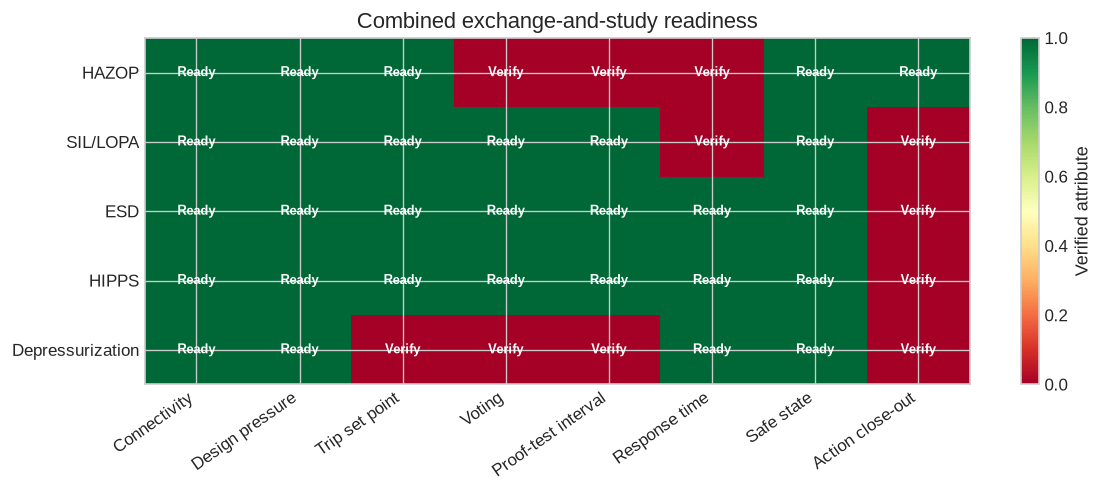

In [14]:
readiness = pd.DataFrame(
    {
        "Connectivity": [1, 1, 1, 1, 1],
        "Design pressure": [1, 1, 1, 1, 1],
        "Trip set point": [1, 1, 1, 1, 0],
        "Voting": [0, 1, 1, 1, 0],
        "Proof-test interval": [0, 1, 1, 1, 0],
        "Response time": [0, 0, 1, 1, 1],
        "Safe state": [1, 1, 1, 1, 1],
        "Action close-out": [1, 0, 0, 0, 0],
    },
    index=["HAZOP", "SIL/LOPA", "ESD", "HIPPS", "Depressurization"],
)
readiness["Coverage"] = readiness.mean(axis=1)
display(readiness.style.format({"Coverage": "{:.0%}"}))

fig, ax = plt.subplots(figsize=(10, 4.2))
matrix = readiness.drop(columns="Coverage")
image = ax.imshow(matrix.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(matrix.columns)), matrix.columns, rotation=35, ha="right")
ax.set_yticks(range(len(matrix.index)), matrix.index)
for row in range(matrix.shape[0]):
    for column in range(matrix.shape[1]):
        label = "Ready" if matrix.iloc[row, column] else "Verify"
        ax.text(
            column,
            row,
            label,
            ha="center",
            va="center",
            fontsize=8,
            color="white",
            fontweight="bold",
        )
ax.set_title("Combined exchange-and-study readiness")
fig.colorbar(image, ax=ax, label="Verified attribute")
plt.tight_layout()
plt.show()

## Current-master result and remaining profile boundary

[NeqSim issue #2653](https://github.com/equinor/neqsim/issues/2653) is resolved:
this run observes the HIPPS final element as a `GateValve` and observes SIL 3,
2oo3 voting, sensor membership, proof-test interval, closure time, safe state,
and SIS control-system attributes in the Proteus P&ID exchange.

The assessed native DEXPI 2.0 Process/PFD profile is generated from the canonical
engineering graph. It records stable material topology, calculated/review-required
provenance, the `NORMAL-001` operating case, explicit mass-flow, absolute-pressure,
and temperature units, and every unsupported scope as a structured diagnostic.

The native Plant/P&ID profile does not currently carry NeqSim-specific HIPPS
extensions, and none of the generated profiles carries the illustrative 82 bara
trip set point as a typed attribute. Keep that set point in the controlled SIF/C&E
register and join it by stable identifiers. Native Process/PFD also reports
multi-area hierarchy, document/sheet semantics, and governed graphics as
unsupported; it is not a professional P&ID renderer.

These are explicit profile boundaries, not evidence of failed native-conformance
checks. Named CAE product/version import and reviewed round-trip evidence remain
unqualified. Further work is tracked in
[campaign issue #2899](https://github.com/equinor/neqsim/issues/2899).


## Validation checks

These checks protect physical plausibility, exact semantic mappings, deterministic
profile selection, and the observed loss boundary. They do not confer engineering
approval.

In [15]:
required_proteus_safety_attributes = [
    ("SafetyIntegrityLevel", "3", None),
    ("VotingArchitecture", "2oo3", None),
    ("ProofTestInterval", "8760", "h"),
    ("ClosureTime", "6", "s"),
    ("SafeState", "Closed", None),
    ("ControlSystem", "SIS", None),
]
proteus_safety_mapping_complete = all(
    has_generic_attribute(proteus_attributes, name, value, unit)
    for name, value, unit in required_proteus_safety_attributes
)
native_hipps_extensions_absent = all(
    not has_generic_attribute(native_attributes, name, value, unit)
    for name, value, unit in required_proteus_safety_attributes
)

checks = {
    "mass_balance_relative_error_below_1e-6": (
        abs(mass_in - mass_out) / mass_in < 1.0e-6
    ),
    "proteus_profile_is_explicit": proteus_schema_version == "4.1.1",
    "proteus_semantic_output_is_deterministic": (
        proteus_semantic_digest == proteus_repeat_semantic_digest
    ),
    "native_dexpi_2_output_is_byte_deterministic": (
        native_payload == native_repeat_payload
    ),
    "native_dexpi_2_process_output_is_byte_deterministic": (
        process_payload == process_repeat_payload
    ),
    "native_dexpi_2_process_report_is_deterministic": (
        str(process_report.toJson()) == str(process_repeat_report.toJson())
    ),
    "native_dexpi_2_process_topology_and_profile_valid": (
        process_report.isSchemaProfileAndSupportedTopologyValid()
    ),
    "native_dexpi_2_process_uses_canonical_topology": (
        str(process_report.getExportTopologySource())
        == "CANONICAL_ENGINEERING_GRAPH"
    ),
    "native_dexpi_2_process_uses_canonical_case_values": (
        str(process_report.getExportOperatingValueSource())
        == "CANONICAL_ENGINEERING_GRAPH_CALCULATION_NODES"
    ),
    "native_dexpi_2_process_reports_missing_case_values": (
        "DEXPI_PROCESS_OPERATING_VALUE_MISSING"
        in process_diagnostic_codes
    ),
    "native_dexpi_2_schema_and_profile_conformant": (
        native_report.isSchemaAndProfileConformant()
    ),
    "native_dexpi_2_report_has_no_errors": (
        len(native_report.getErrors()) == 0
    ),
    "protected_equipment_tag_present": "V-101" in proteus_payload.decode(),
    "hipps_exported_as_gate_valve": hipps_gate_valve,
    "three_pressure_sensor_tags_present": all(
        f"PSHH-101{x}" in proteus_payload.decode()
        for x in "ABC"
    ),
    "proteus_safety_mapping_complete": proteus_safety_mapping_complete,
    "native_hipps_profile_boundary_observed": native_hipps_extensions_absent,
    "trip_set_point_externalized": (
        not has_generic_attribute(
            proteus_attributes,
            "TripSetPoint",
            "82",
            "bara",
        )
        and not has_generic_attribute(
            native_attributes,
            "TripSetPoint",
            "82",
            "bara",
        )
    ),
    "hazop_nodes_have_unique_ids": hazop_nodes["Node"].is_unique,
    "cause_effect_functions_have_ids": cause_effect["Function"].notna().all(),
}
validation = pd.DataFrame(
    [{"Check": key, "Pass": bool(value)} for key, value in checks.items()]
)
display(validation)
assert validation["Pass"].all(), validation


,Check,Pass
0,mass_balance_relative_error_below_1e-6,True
1,proteus_profile_is_explicit,True
2,proteus_semantic_output_is_deterministic,True
3,native_dexpi_2_output_is_byte_deterministic,True
4,native_dexpi_2_process_output_is_byte_determin...,True
5,native_dexpi_2_process_report_is_deterministic,True
6,native_dexpi_2_process_topology_and_profile_valid,True
7,native_dexpi_2_process_uses_canonical_topology,True
8,native_dexpi_2_process_uses_canonical_case_values,True
9,native_dexpi_2_process_reports_missing_case_va...,True


## What to do next

1. Replace synthetic tags and limits with a controlled project design basis.
2. Select and document the intended exchange profile before export.
3. Use `DexpiEngineeringExporter` when provenance, revision, validation,
   registers, and manifest evidence are required as one governed package.
4. Validate native DEXPI files against the applicable profile and validate
   graphical P&ID files against the receiving workflow.
5. Qualify each named CAE product and version with observed import and reviewed
   round-trip evidence before making an interoperability claim.
6. Reconcile the semantic graph with line lists, instrument indexes, C&E, SRS,
   relief registers, and the HAZOP action log.
7. Record source, owner, engineering state (`calculated`, `inferred`, `verified`,
   `reviewed`, or `approved`), and change history for every governed attribute.
8. Re-run traceability checks after each P&ID or safety-study revision.

Useful exercises are to add a PSV, distinguish process-control and SIS sensors,
model a bypass with administrative controls, and calculate semantic deltas between
two document revisions.

## References

- [NeqSim DEXPI guide](https://equinor.github.io/neqsim/engineering/dexpi-guide)
- [NeqSim DEXPI 2.0 conformance](https://equinor.github.io/neqsim/integration/dexpi-20-conformance)
- [NeqSim engineering-generation guide](https://equinor.github.io/neqsim/integration/dexpi-engineering-generation)
- [DEXPI specifications](https://dexpi.org/specifications/)
- [DEXPI 2.0 publication](https://dexpi.org/dexpi-2-0-specification-published-a-new-standard-for-process-industry-data-exchange/)
- [IEC 62424:2016](https://webstore.iec.ch/en/publication/25442)
- [IEC 61882:2016](https://webstore.iec.ch/en/publication/24321)
- [IEC 61511-1:2016](https://webstore.iec.ch/en/publication/24241)
- [Resolved NeqSim issue #2653](https://github.com/equinor/neqsim/issues/2653)
- [Professional DEXPI and P&ID campaign #2899](https://github.com/equinor/neqsim/issues/2899)